In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", context="notebook")

In [50]:
DATA_DIR = Path.cwd()
CSV_FILES = {
    "sales": "SALES.csv",
    "company": "COMPANY_LOOKUP.csv",
    "items": "ITEM_LOOKUP.csv",
    "business_lines": "ITEM_BUSINESS_LINE_LOOKUP.csv",
    "customers": "CUSTOMER_LOOKUP.csv",
    "area_managers": "AREA_MANAGER_LOOKUP.csv",
}

def load_dataset(filename):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")
    return pd.read_csv(path)

def load_datasets():
    return {name: load_dataset(filename) for name, filename in CSV_FILES.items()}

def remove_duplicates(df):
    return df.drop_duplicates().reset_index(drop=True)

def merge_datasets(datasets):
    df = datasets["sales"].merge(datasets["company"], on="ID_COMPANY", how="left")
    df = df.merge(datasets["items"], on="IDS_ITEM", how="left")
    df = df.merge(datasets["business_lines"], on="ID_BUSINESS_LINE", how="left")
    df = df.merge(datasets["customers"], on="IDS_CUSTOMER", how="left")
    df = df.merge(datasets["area_managers"], on="ID_AREA_MANAGER", how="left")
    return df

def convert_date_column(series):
    parsed = pd.to_datetime(series, format="%Y%m%d", errors="coerce")
    lower_bound = pd.Timestamp("1900-01-01")
    upper_bound = pd.Timestamp.today().normalize()
    parsed = parsed.mask((parsed < lower_bound) | (parsed > upper_bound))
    if parsed.notna().any():
        parsed = parsed.fillna(parsed.median())
    return parsed

def clean_date_columns(df):
    df = df.copy()
    for column in ["ID_INVOICE_DATE", "ID_ORDER_DATE"]:
        if column in df.columns:
            df[column] = convert_date_column(df[column])
    return df

def add_calendar_features(df):
    df = df.copy()
    if "ID_ORDER_DATE" in df.columns:
        df["ORDER_YEAR"] = df["ID_ORDER_DATE"].dt.year
        df["ORDER_QUARTER"] = df["ID_ORDER_DATE"].dt.quarter
        df["ORDER_MONTH"] = df["ID_ORDER_DATE"].dt.month
        df["ORDER_MONTH_NAME"] = df["ID_ORDER_DATE"].dt.month_name()
    return df

In [51]:
def dataset_overview(df):
    print("\n1. DIMENSIONE E STRUTTURA DEL DATASET")
    print(f"Righe: {df.shape[0]}")
    print(f"Colonne: {df.shape[1]}")
    display(df.head())

    print("\n2. TIPI DI DATO")
    display(df.dtypes.to_frame("dtype"))

    print("\n3. VALORI MANCANTI")
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        print("Nessun valore mancante")
    else:
        display(missing.to_frame("missing_values"))

    print("\n4. DUPLICATI")
    duplicate_rows = df.duplicated().sum()
    print(f"Righe duplicate: {duplicate_rows}")

def descriptive_numeric_analysis(df):
    numeric_df = df.select_dtypes(include=np.number)
    print("\n5. STATISTICHE DESCRITTIVE NUMERICHE")
    if numeric_df.empty:
        print("Nessuna colonna numerica trovata")
        return

    summary = numeric_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    summary["missing"] = numeric_df.isna().sum()
    summary["skewness"] = numeric_df.skew(numeric_only=True)
    summary["kurtosis"] = numeric_df.kurtosis(numeric_only=True)
    display(summary.round(2))

def target_analysis(df, target_col="VAL_REVENUES"):
    if target_col not in df.columns:
        print(f"\nLa colonna target {target_col} non è presente nel dataset.")
        return

    print("\n6. ANALISI DEL TARGET")
    target = df[target_col].dropna()
    display(target.describe().to_frame(name=target_col).T.round(2))

    plt.figure(figsize=(12, 4))
    sns.histplot(target, bins=50, kde=True, color="#2a6f97")
    plt.title(f"Distribuzione di {target_col}")
    plt.xlabel(target_col)
    plt.ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 2.8))
    sns.boxplot(x=target, color="#ffb703")
    plt.title(f"Boxplot di {target_col}")
    plt.tight_layout()
    plt.show()

    q1 = target.quantile(0.25)
    q3 = target.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[target_col] < lower) | (df[target_col] > upper)]

    print(f"Outlier individuati: {len(outliers)}")
    if len(df) > 0:
        print(f"Incidenza outlier: {(len(outliers) / len(df)) * 100:.2f}%")

In [52]:
def correlation_analysis(df, target_col="VAL_REVENUES"):
    print("\n7. MATRICE DI CORRELAZIONE")

    numeric_df = df.select_dtypes(include=np.number)
    if numeric_df.shape[1] < 2:
        print("Non ci sono abbastanza colonne numeriche per calcolare la correlazione.")
        return

    corr = numeric_df.corr().round(2)

    print("\nMatrice di correlazione completa:")
    display(corr)

    plt.figure(figsize=(max(10, 0.65 * corr.shape[1]), max(8, 0.65 * corr.shape[0])))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

    if target_col in corr.columns:
        print(f"\nCorrelazioni ordinate rispetto a {target_col}:")
        target_corr = corr[target_col].drop(labels=[target_col]).sort_values(ascending=False)
        display(target_corr.to_frame(name=f"corr_with_{target_col}"))

def seasonal_decomposition(monthly_df, target_col="VAL_REVENUES"):
    print("\n9.1 SEASONAL DECOMPOSITION")
    
    if "revenue_mean" not in monthly_df.columns and "orders" not in monthly_df.columns:
        print("Dati insufficienti per la seasonal decomposition.")
        return
    
    column_to_decompose = "revenue_mean" if "revenue_mean" in monthly_df.columns else "orders"
    ts = monthly_df.set_index("YEAR_MONTH")[column_to_decompose].astype(float)
    
    if len(ts) < 4:
        print("Serie temporale troppo breve per la decomposizione stagionale.")
        return
    
    period = min(12, max(4, len(ts) // 3))
    
    try:
        decomposition = seasonal_decompose(ts, model="additive", period=period)
        
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
        
        ax1.plot(decomposition.observed, color="#1d3557", linewidth=2)
        ax1.set_ylabel("Osservato")
        ax1.set_title("Seasonal Decomposition")
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(decomposition.trend, color="#f77f00", linewidth=2)
        ax2.set_ylabel("Trend")
        ax2.grid(True, alpha=0.3)
        
        ax3.plot(decomposition.seasonal, color="#06a77d", linewidth=2)
        ax3.set_ylabel("Stagionale")
        ax3.grid(True, alpha=0.3)
        
        ax4.plot(decomposition.resid, color="#d62828", linewidth=1)
        ax4.set_ylabel("Residuo")
        ax4.set_xlabel("Data")
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nPeriodo stagionale: {period} mesi")
        print(f"Variabilità trend: {decomposition.trend.std():.2f}")
        print(f"Variabilità stagionale: {decomposition.seasonal.std():.2f}")
        print(f"Variabilità residuo: {decomposition.resid.std():.2f}")
        
    except Exception as e:
        print(f"Errore nella decomposizione stagionale: {type(e).__name__}: {str(e)}")

def categorical_analysis(df, target_col="VAL_REVENUES", max_columns=5, top_n=10):
    print("\n8. ANALISI DELLE VARIABILI CATEGORICHE")

    categorical_cols = [
        col for col in df.select_dtypes(include=["object"]).columns
        if df[col].nunique(dropna=True) > 1
    ]

    if not categorical_cols:
        print("Nessuna colonna categorica trovata")
        return

    for col in categorical_cols[:max_columns]:
        print(f"\n--- {col} ---")
        counts = df[col].fillna("<NA>").value_counts().head(top_n)
        display(counts.to_frame("frequency"))

        if target_col in df.columns and pd.api.types.is_numeric_dtype(df[target_col]):
            grouped = (
                df.groupby(col, dropna=False)[target_col]
                .agg(count="count", mean="mean", sum="sum")
                .sort_values("sum", ascending=False)
                .head(top_n)
            )
            display(grouped.round(2))

            plt.figure(figsize=(12, 4))
            grouped["mean"].sort_values(ascending=False).plot(kind="bar", color="#3a7ca5")
            plt.title(f"Media di {target_col} per {col}")
            plt.ylabel(f"Media {target_col}")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

def temporal_analysis(df, target_col="VAL_REVENUES"):
    print("\n9. ANALISI TEMPORALE")

    if "ID_ORDER_DATE" not in df.columns:
        print("La colonna ID_ORDER_DATE non è presente nel dataset.")
        return

    temporal_df = df.dropna(subset=["ID_ORDER_DATE"]).copy()
    if temporal_df.empty:
        print("Nessuna data valida disponibile per l'analisi temporale.")
        return

    temporal_df["YEAR_MONTH"] = temporal_df["ID_ORDER_DATE"].dt.to_period("M").dt.to_timestamp()

    monthly = temporal_df.groupby("YEAR_MONTH").agg(
        orders=("YEAR_MONTH", "size"),
        revenue_mean=(target_col, "mean") if target_col in temporal_df.columns else ("YEAR_MONTH", "size"),
        revenue_sum=(target_col, "sum") if target_col in temporal_df.columns else ("YEAR_MONTH", "size"),
    ).reset_index()

    monthly = monthly.sort_values("YEAR_MONTH").reset_index(drop=True)
    display(monthly.round(2))

    plt.figure(figsize=(12, 4))
    if target_col in temporal_df.columns:
        plt.plot(monthly["YEAR_MONTH"], monthly["revenue_mean"], marker="o", linewidth=2, color="#1d3557")
        plt.ylabel(f"Media {target_col}")
    else:
        plt.plot(monthly["YEAR_MONTH"], monthly["orders"], marker="o", linewidth=2, color="#1d3557")
        plt.ylabel("Numero ordini")
    plt.title("Andamento mensile")
    plt.xlabel("Mese")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    seasonal_decomposition(monthly, target_col=target_col)

In [53]:
def build_clean_dataset():
    datasets = load_datasets()
    df = merge_datasets(datasets)
    df = remove_duplicates(df)
    df = clean_date_columns(df)
    return df

def full_statistical_analysis(df, target_col="VAL_REVENUES"):
    dataset_overview(df)
    descriptive_numeric_analysis(df)
    target_analysis(df, target_col=target_col)
    correlation_analysis(df, target_col=target_col)
    categorical_analysis(df, target_col=target_col)
    temporal_analysis(df, target_col=target_col)

def run_analysis(target_col="VAL_REVENUES"):
    print("Avvio costruzione dataset pulito...")
    df = build_clean_dataset()
    print("Dataset costruito. Avvio analisi statistica completa...")
    full_statistical_analysis(df, target_col=target_col)
    print("Analisi completata.")
    return df

Caricamento dei dataset...
Unione dei dataset...
Rimozione duplicati e pulizia date...
Avvio delle analisi...

1. DIMENSIONE E STRUTTURA DEL DATASET
Righe: 213
Colonne: 16


,ID_COMPANY,ID_ORDER_NUM,IDS_CUSTOMER,IDS_ITEM,ID_ORDER_DATE,ID_INVOICE_DATE,VAL_REVENUES,VAL_COST,DESC_COMPANY,DESC_ITEM,ID_BUSINESS_LINE,DESC_BUSINESS_LINE,DESC_CUSTOMER,ID_COUNTRY,ID_AREA_MANAGER,DESC_AREA_MANAGER
0,40,25437824,00040-456235,7273238-405MAG,2025-05-15,2025-05-23,35406.6,18386.9818,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
1,40,25428861,00040-456235,7273238-405MAG,2025-03-31,2025-06-20,40291.0,18276.8717,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
2,40,25473527,00040-456235,7273238-405MAG,2025-11-17,2025-12-11,40499.2,22015.9190,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
3,40,26422305,00040-456235,7479346-405MAG,2026-03-02,2025-09-26,27647.8,12458.2338,COMPANY 00040,ITEM 7479346-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
4,80640,25400075,80640-1048669,7278569-W401MAG,2025-01-10,2025-02-06,21904.0,8243.9502,COMPANY 80640,ITEM 7278569-W401MAG,4C7,BL 4C7,CUSTOMER 80640-1048669,CA,4E1,AREA MANAGER 4E1



2. TIPI DI DATO


,dtype
ID_COMPANY,int64
ID_ORDER_NUM,int64
IDS_CUSTOMER,object
IDS_ITEM,object
ID_ORDER_DATE,datetime64[ns]
ID_INVOICE_DATE,datetime64[ns]
VAL_REVENUES,float64
VAL_COST,float64
DESC_COMPANY,object
DESC_ITEM,object



3. VALORI MANCANTI
Nessun valore mancante

4. DUPLICATI
Righe duplicate: 0

5. STATISTICHE DESCRITTIVE NUMERICHE


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,skewness,kurtosis
ID_COMPANY,213.0,37501.97,40294.64,40.00,40.00,40.00,40.0,40.00,80640.0,80640.00,80640.00,80640.0,0,0.14,-2.00
ID_ORDER_NUM,213.0,25554589.18,328889.58,25400051.00,25400075.84,25400238.80,25401532.0,25435451.00,25471810.0,26417802.00,26424295.80,26426822.0,0,2.23,3.05
VAL_REVENUES,213.0,34953.30,16510.66,20329.61,20392.38,22099.36,25666.0,32724.00,39596.4,53982.60,97175.59,169160.4,0,5.46,40.90
VAL_COST,213.0,17310.98,9019.33,7096.63,8335.55,9506.81,11998.0,17343.75,20171.5,26225.83,52959.01,86154.6,0,4.59,31.88



6. ANALISI DEL TARGET


,count,mean,std,min,25%,50%,75%,max
VAL_REVENUES,213.0,34953.3,16510.66,20329.61,25666.0,32724.0,39596.4,169160.4


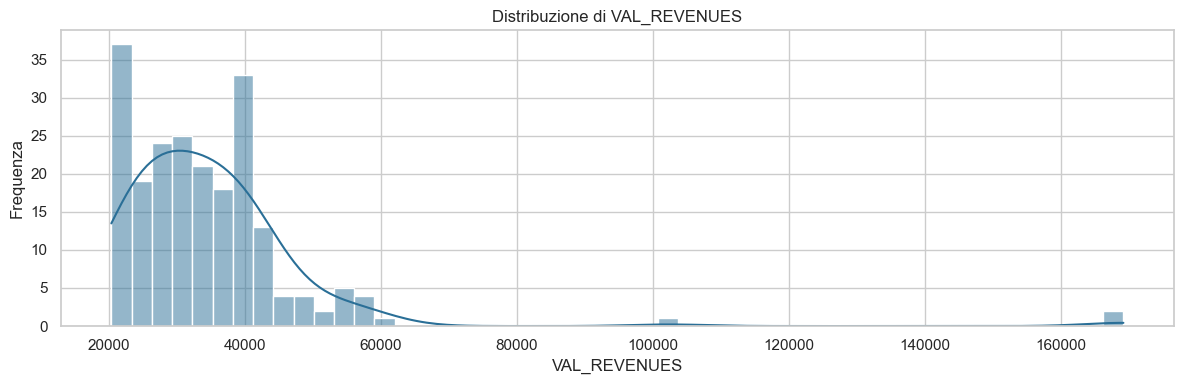

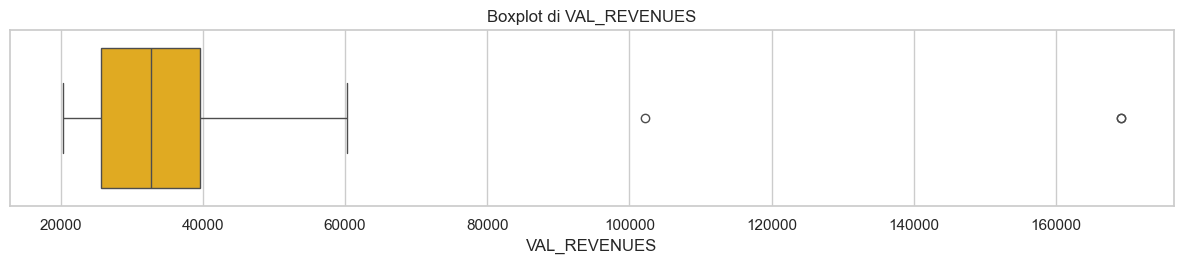

Outlier individuati: 3
Incidenza outlier: 1.41%

7. MATRICE DI CORRELAZIONE

Matrice di correlazione completa:


,ID_COMPANY,ID_ORDER_NUM,VAL_REVENUES,VAL_COST
ID_COMPANY,1.00,-0.18,0.39,0.38
ID_ORDER_NUM,-0.18,1.00,-0.08,-0.09
VAL_REVENUES,0.39,-0.08,1.00,0.95
VAL_COST,0.38,-0.09,0.95,1.00


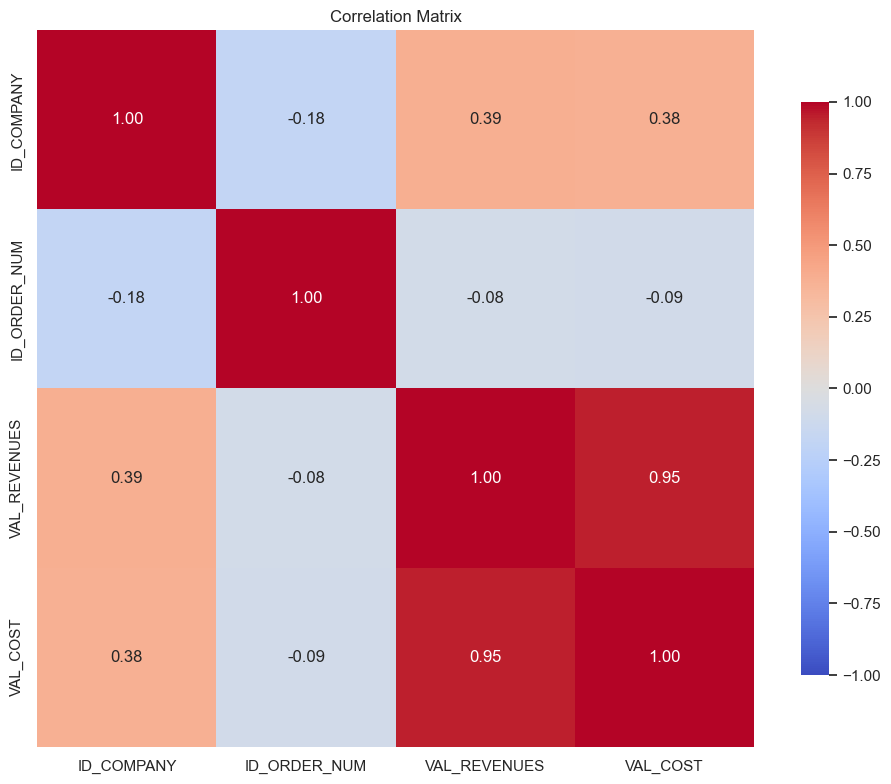


Correlazioni ordinate rispetto a VAL_REVENUES:


,corr_with_VAL_REVENUES
VAL_COST,0.95
ID_COMPANY,0.39
ID_ORDER_NUM,-0.08



8. ANALISI DELLE VARIABILI CATEGORICHE

--- IDS_CUSTOMER ---


,frequency
IDS_CUSTOMER,
00040-10277,24
00040-45887,17
80640-207312,15
80640-615382,8
00040-209369,7
00040-42576,7
80640-459504,6
00040-456235,4
80640-408385,4


,count,mean,sum
IDS_CUSTOMER,,,
00040-10277,24,25313.29,607519.03
80640-207312,15,35992.31,539884.69
00040-45887,17,31154.90,529633.26
80640-308899,2,169160.40,338320.80
80640-615382,8,40924.30,327394.40
80640-444800,4,63015.62,252062.48
80640-459504,6,41819.81,250918.86
00040-209369,7,33508.82,234561.71
00040-42576,7,30430.88,213016.17


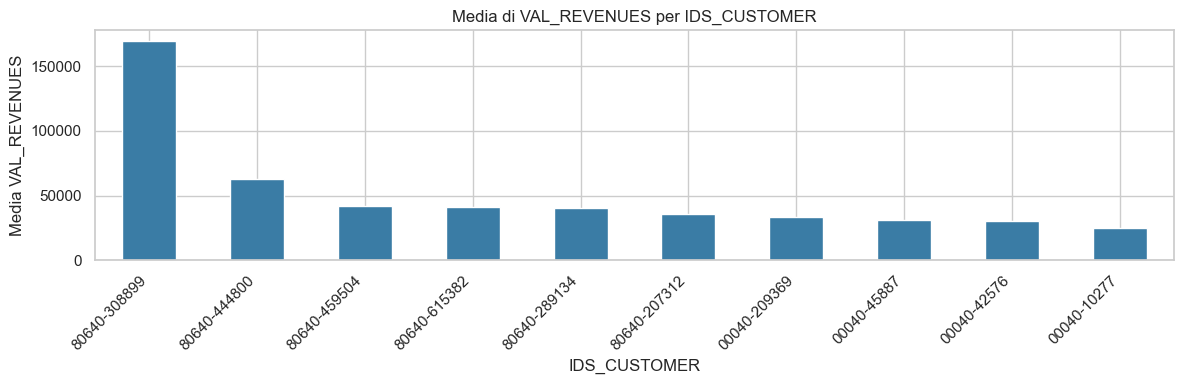


--- IDS_ITEM ---


,frequency
IDS_ITEM,
7245498-W401MAG,38
7481581-405MAG,30
7273238-405MAG,29
7245502-W401MAG,15
7344923-W401MAG,14
7479346-405MAG,14
7195806-405MAG,12
7273191-405MAG,10
7481582-405MAG,9


,count,mean,sum
IDS_ITEM,,,
7245498-W401MAG,38,37379.30,1420413.29
7273238-405MAG,29,35983.80,1043530.28
7344923-W401MAG,14,50961.35,713458.85
7481581-405MAG,30,22606.87,678206.17
7245502-W401MAG,15,40749.54,611243.13
7479346-405MAG,14,30295.32,424134.50
7270011-W401MAG,2,169160.40,338320.80
7195806-405MAG,12,26747.99,320975.88
7273191-405MAG,10,30708.54,307085.40


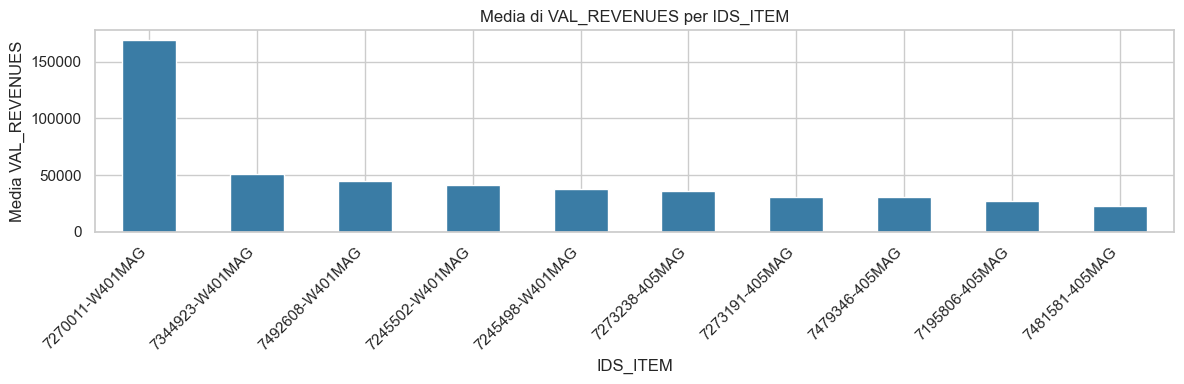


--- DESC_COMPANY ---


,frequency
DESC_COMPANY,
COMPANY 00040,114
COMPANY 80640,99


,count,mean,sum
DESC_COMPANY,,,
COMPANY 80640,99,41807.10,4138902.99
COMPANY 00040,114,29001.31,3306149.08


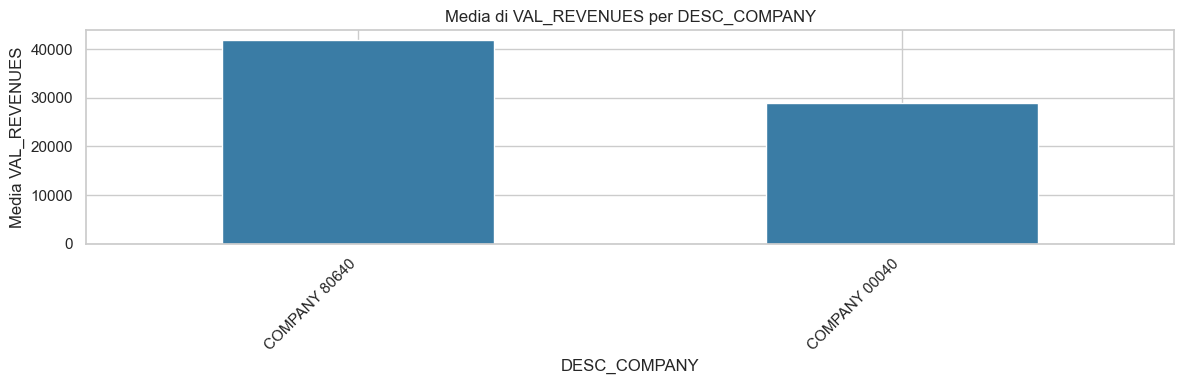


--- DESC_ITEM ---


,frequency
DESC_ITEM,
ITEM 7245498-W401MAG,38
ITEM 7481581-405MAG,30
ITEM 7273238-405MAG,29
ITEM 7245502-W401MAG,15
ITEM 7344923-W401MAG,14
ITEM 7479346-405MAG,14
ITEM 7195806-405MAG,12
ITEM 7273191-405MAG,10
ITEM 7481582-405MAG,9


,count,mean,sum
DESC_ITEM,,,
ITEM 7245498-W401MAG,38,37379.30,1420413.29
ITEM 7273238-405MAG,29,35983.80,1043530.28
ITEM 7344923-W401MAG,14,50961.35,713458.85
ITEM 7481581-405MAG,30,22606.87,678206.17
ITEM 7245502-W401MAG,15,40749.54,611243.13
ITEM 7479346-405MAG,14,30295.32,424134.50
ITEM 7270011-W401MAG,2,169160.40,338320.80
ITEM 7195806-405MAG,12,26747.99,320975.88
ITEM 7273191-405MAG,10,30708.54,307085.40


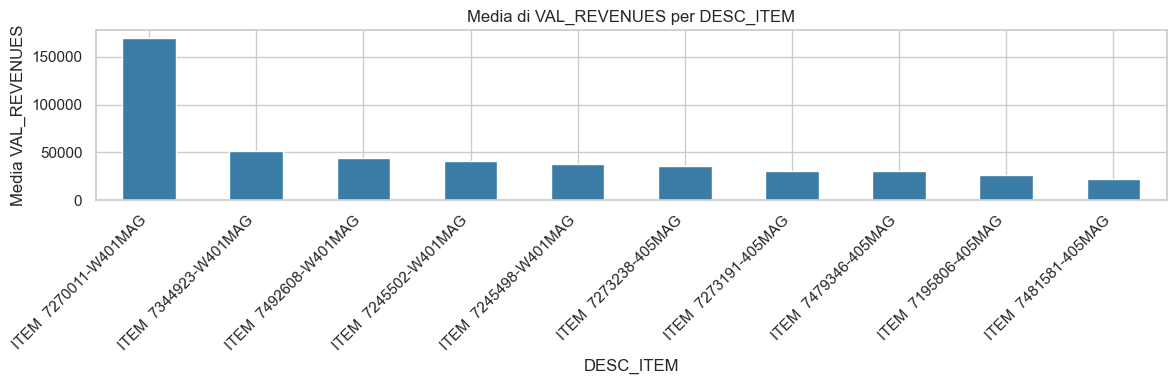


--- ID_BUSINESS_LINE ---


,frequency
ID_BUSINESS_LINE,
4C7,208
4C1,5


,count,mean,sum
ID_BUSINESS_LINE,,,
4C7,208,35220.99,7325965.87
4C1,5,23817.24,119086.20


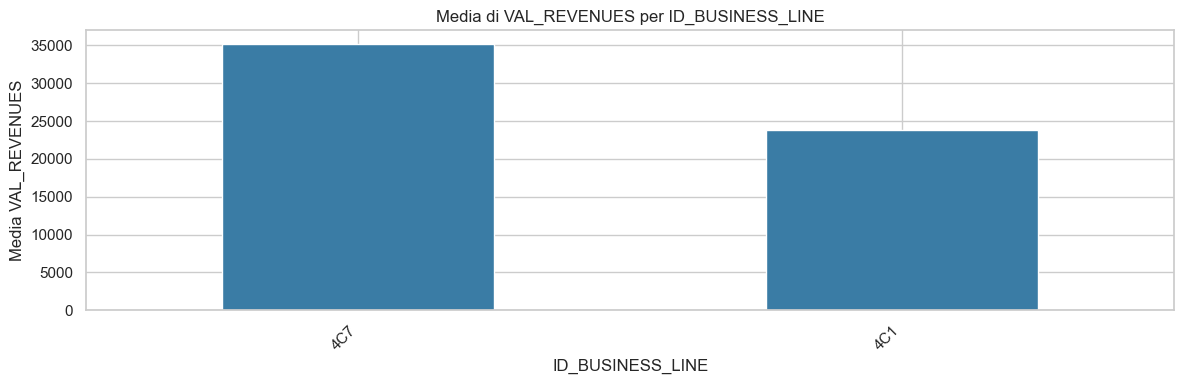


9. ANALISI TEMPORALE


,YEAR_MONTH,orders,revenue_mean,revenue_sum
0,2025-01-01,8,33386.16,267089.30
1,2025-02-01,12,39705.99,476471.83
2,2025-03-01,11,38900.05,427900.51
3,2025-04-01,20,33304.67,666093.39
4,2025-05-01,8,37145.70,297165.62
5,2025-06-01,14,36104.99,505469.91
6,2025-07-01,17,31470.10,534991.69
7,2025-08-01,9,42868.09,385812.78
8,2025-09-01,11,30689.54,337584.99
9,2025-10-01,27,29254.91,789882.60


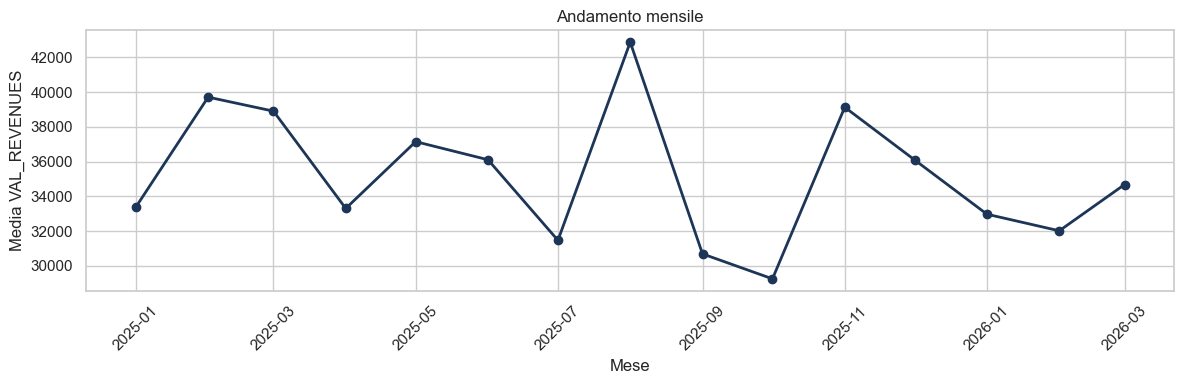


9.1 SEASONAL DECOMPOSITION


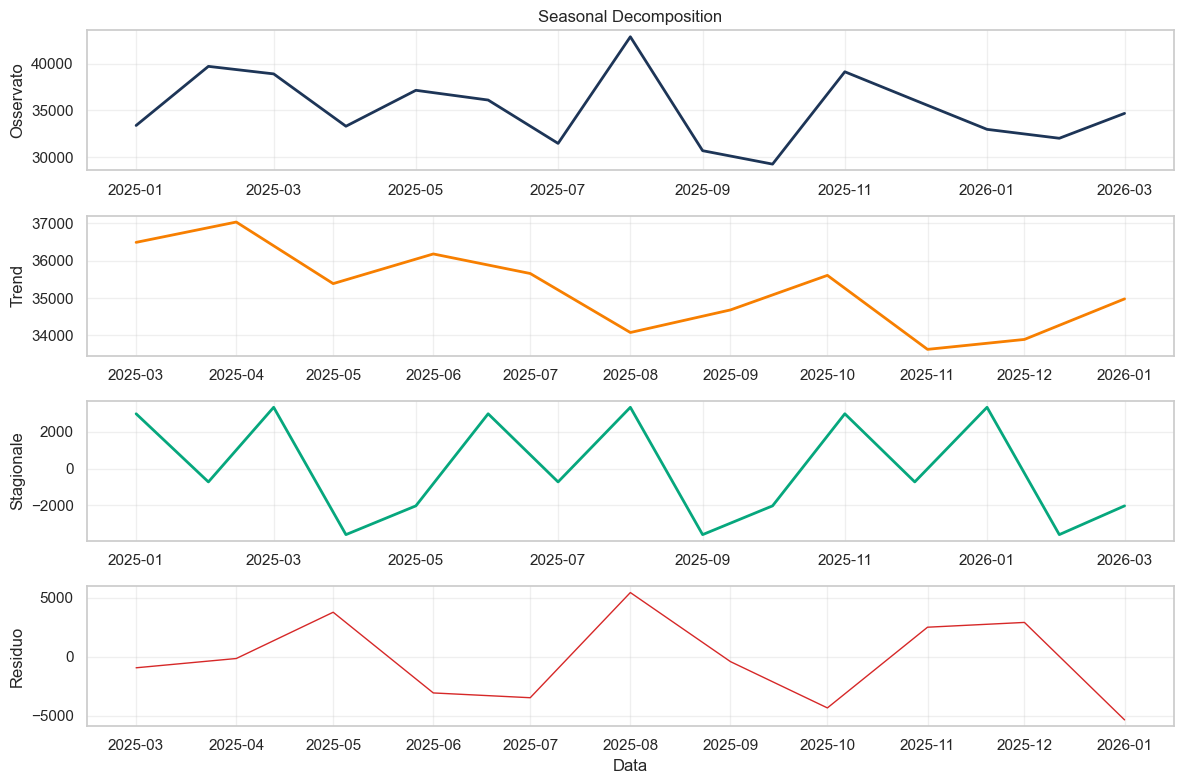


Periodo stagionale: 5 mesi
Variabilità trend: 1101.46
Variabilità stagionale: 2836.05
Variabilità residuo: 3574.36
Analisi terminata.


,ID_COMPANY,ID_ORDER_NUM,IDS_CUSTOMER,IDS_ITEM,ID_ORDER_DATE,ID_INVOICE_DATE,VAL_REVENUES,VAL_COST,DESC_COMPANY,DESC_ITEM,ID_BUSINESS_LINE,DESC_BUSINESS_LINE,DESC_CUSTOMER,ID_COUNTRY,ID_AREA_MANAGER,DESC_AREA_MANAGER
0,40,25437824,00040-456235,7273238-405MAG,2025-05-15,2025-05-23,35406.6,18386.9818,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
1,40,25428861,00040-456235,7273238-405MAG,2025-03-31,2025-06-20,40291.0,18276.8717,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
2,40,25473527,00040-456235,7273238-405MAG,2025-11-17,2025-12-11,40499.2,22015.9190,COMPANY 00040,ITEM 7273238-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
3,40,26422305,00040-456235,7479346-405MAG,2026-03-02,2025-09-26,27647.8,12458.2338,COMPANY 00040,ITEM 7479346-405MAG,4C7,BL 4C7,CUSTOMER 00040-456235,IT,4N4,AREA MANAGER 4N4
4,80640,25400075,80640-1048669,7278569-W401MAG,2025-01-10,2025-02-06,21904.0,8243.9502,COMPANY 80640,ITEM 7278569-W401MAG,4C7,BL 4C7,CUSTOMER 80640-1048669,CA,4E1,AREA MANAGER 4E1


In [54]:
# Esecuzione principale
print("Caricamento dei dataset...")
datasets = load_datasets()
print("Unione dei dataset...")
df = merge_datasets(datasets)
print("Rimozione duplicati e pulizia date...")
df = remove_duplicates(df)
df = clean_date_columns(df)
print("Avvio delle analisi...")
dataset_overview(df)
descriptive_numeric_analysis(df)
target_analysis(df, target_col="VAL_REVENUES")
correlation_analysis(df, target_col="VAL_REVENUES")
categorical_analysis(df, target_col="VAL_REVENUES")
temporal_analysis(df, target_col="VAL_REVENUES")
print("Analisi terminata.")
df.head()